# Merton jump-diffusion: adding jumps to Black-Scholes

Every model so far moves the price *continuously*: Brownian motion has continuous
paths, so over a tiny time step the price wiggles but never teleports. Merton
(1976) adds a second source of randomness, sudden discontinuous *jumps*, on top
of the diffusion. This notebook derives the Merton characteristic function from
first principles, then (Tuesday) implements and validates it, reusing the COS
and Carr-Madan Fourier machinery from Week 5.

The motivation is empirical. Last week we measured a very steep short-dated SPX
skew (rho near -0.99 at 29 DTE). A pure diffusion cannot produce that: over a
short horizon its log-return is nearly Gaussian, so its tails are thin, so deep
OTM puts should be nearly worthless and there should be almost no skew. The
market says otherwise. Jumps put genuine weight in the short-dated tail, because
a jump can occur in any interval however short, and that is exactly what a rich
deep-OTM put price requires.

## 1. The model

Under the risk-neutral measure, the log-price follows a diffusion plus a
compound Poisson jump term:

$$d(\log S_t) = \left(r - q - \tfrac12\sigma^2 - \lambda\kappa\right)dt
+ \sigma\, dW_t + dJ_t$$

Two pieces of randomness:

- **Diffusion**: $\sigma\, dW_t$, the usual Brownian part.
- **Jumps**: $dJ_t$, a compound Poisson process. Jumps arrive at Poisson rate
  $\lambda$ (average jumps per year). When a jump occurs, the log-price moves by
  a random amount $Y \sim \mathcal{N}(\mu_J, \delta_J^2)$. So Merton's jump sizes
  are **normally distributed in log-space**, which makes the jump multiplier on
  the price lognormal.

The parameters:

- $\sigma$: diffusion volatility (as in BSM).
- $\lambda$: jump intensity, expected number of jumps per year.
- $\mu_J$: mean jump size in log-space (negative $\mu_J$ = jumps tend downward,
  the crash-risk direction).
- $\delta_J$: standard deviation of jump size in log-space.

### The martingale correction

The drift term has an extra piece, $-\lambda\kappa$, that is not in BSM. It is a
compensator that keeps the discounted price a martingale (risk-neutral pricing
requires $E[S_T] = S_0 e^{(r-q)T}$). Jumps add expected growth, so the drift must
be pushed down to cancel it. The size of that expected jump contribution is

$$\kappa = E[e^Y - 1] = e^{\mu_J + \tfrac12\delta_J^2} - 1$$

which is just the expected proportional price change per jump ($e^Y$ is the price
multiplier, $E[e^Y]$ for a lognormal is $e^{\mu_J + \delta_J^2/2}$). Multiply by
$\lambda$ (jumps per year) and subtract in the drift, and the mean jump growth is
exactly compensated. This is the same martingale-correction logic as the Heston
K0 term, applied to jumps instead of stochastic variance.

## 2. The characteristic function, derived

The characteristic function of the log-price is
$\phi(u) = E[e^{iu \log S_T}]$. It is the object the COS and Carr-Madan pricers
consume, so deriving it is the whole job. The derivation rests on one clean fact:

**The diffusion and the jumps are independent.** Independent random variables
have characteristic functions that *multiply*. So the Merton char func factorises:

$$\phi_{\text{Merton}}(u) = \phi_{\text{diffusion}}(u) \cdot \phi_{\text{jump}}(u)$$

The first factor you already know, it is the BSM log-price char func (a Gaussian).
The only new work is the jump factor.

### The jump factor via conditioning on the number of jumps

Over horizon $\tau$, let $N$ be the number of jumps, which is Poisson with mean
$\lambda\tau$: $P(N = n) = e^{-\lambda\tau}(\lambda\tau)^n / n!$. Given $N = n$
jumps, the total jump contribution is a sum of $n$ iid normal jump sizes, which
is itself normal: $\sum_{i=1}^n Y_i \sim \mathcal{N}(n\mu_J, n\delta_J^2)$.

Condition on $N$ and use the tower property:

$$\phi_{\text{jump}}(u) = E\!\left[e^{iu \sum_i Y_i}\right]
= \sum_{n=0}^{\infty} P(N=n)\, E\!\left[e^{iu\sum_{i=1}^n Y_i}\right]$$

The inner expectation is the char func of a $\mathcal{N}(n\mu_J, n\delta_J^2)$,
which is $\exp(iu\, n\mu_J - \tfrac12 u^2 n\delta_J^2)$. Substitute:

$$\phi_{\text{jump}}(u)
= \sum_{n=0}^{\infty} \frac{e^{-\lambda\tau}(\lambda\tau)^n}{n!}
\exp\!\left(n\left[iu\mu_J - \tfrac12 u^2\delta_J^2\right]\right)$$

Pull the $n$-dependence together and recognise the exponential series
$\sum_n x^n/n! = e^x$:

$$\phi_{\text{jump}}(u)
= e^{-\lambda\tau}\sum_{n=0}^{\infty}
\frac{\left(\lambda\tau\, e^{iu\mu_J - \frac12 u^2\delta_J^2}\right)^n}{n!}
= \exp\!\left(\lambda\tau\left[e^{iu\mu_J - \frac12 u^2\delta_J^2} - 1\right]\right)$$

That closed form is the entire jump contribution. It is a special case of the
**Levy-Khintchine formula**: the char func of any compound Poisson process is
$\exp(\lambda\tau (\hat{f}(u) - 1))$, where $\hat{f}$ is the char func of a single
jump size. Here the single-jump char func is the Gaussian
$e^{iu\mu_J - u^2\delta_J^2/2}$.

## 3. The full Merton characteristic function

Combine the diffusion factor (BSM Gaussian log-price char func, with the
jump-compensated drift) and the jump factor:

$$\phi_{\text{Merton}}(u) = \exp\!\Big(iu\big(\log S_0 + (r - q - \tfrac12\sigma^2
- \lambda\kappa)\tau\big) - \tfrac12\sigma^2 u^2\tau\Big)
\cdot \exp\!\Big(\lambda\tau\big[e^{iu\mu_J - \frac12 u^2\delta_J^2} - 1\big]\Big)$$

with $\kappa = e^{\mu_J + \delta_J^2/2} - 1$.

Two sanity checks that fall straight out of this form, and both become tests
on Tuesday:

1. **No jumps recovers BSM.** Set $\lambda = 0$. The jump factor becomes
   $e^0 = 1$, and the drift correction $-\lambda\kappa$ vanishes, leaving exactly
   the BSM log-price char func. A jump model must reduce to Black-Scholes when
   jumps are switched off.
2. **The compensator keeps it a martingale.** At $u = -i$ the char func gives
   $E[S_T]$, which must equal $S_0 e^{(r-q)\tau}$. The $-\lambda\kappa\tau$ drift
   term is precisely what makes the jump factor cancel against it. Checking
   $\phi(-i) = S_0 e^{(r-q)\tau}$ numerically is a clean martingale test.

### Why this shape produces short-dated skew

The jump factor does not vanish as $\tau \to 0$ the way a diffusion's tail
contribution does. For any $\tau > 0$ there is probability $\approx \lambda\tau$
of at least one jump, and that jump can be large. So the short-dated return
distribution keeps a fat tail, and with $\mu_J < 0$ (downward jumps) a *left*-fat
tail specifically, which is exactly skew. The diffusion part alone would give a
nearly Gaussian, nearly symmetric, thin-tailed short-dated smile; the jump part
bends it. This is the mechanism that lets Merton reach the steep 29 DTE SPX skew
that Heston, being a pure diffusion in the price, flattens away too fast.

### The limitation, previewing Kou

Merton's jumps are *normal*, so symmetric-ish and light-tailed within the jump
distribution itself. Real crash risk is more asymmetric and heavier-tailed than
a Gaussian jump captures. Kou (Wednesday) replaces the normal jump with a
*double-exponential*, two-sided with different up and down decay rates, giving
fatter and more asymmetric tails, and analytically convenient tails that also
help with certain exotic pricing. Merton first because its Gaussian jump is the
gentler derivation and the direct generalisation of BSM.

In [1]:
# Imports. Reuse the Week 5 Fourier machinery; jump char funcs plug straight in.
import numpy as np
import matplotlib.pyplot as plt
from models.merton import merton_simulate_terminal
from pricing.fourier import merton_cos_price

In [2]:
S0, R, Q, T = 100.0, 0.03, 0.01, 0.5
SIGMA, LAM, MU_J, DELTA_J = 0.20, 0.5, -0.10, 0.15
K = 100.0

cos_p = merton_cos_price(S0, R, Q, T, SIGMA, LAM, MU_J, DELTA_J, K, "call")
ST = merton_simulate_terminal(S0, R, Q, T, SIGMA, LAM, MU_J, DELTA_J,
                              n_paths=2_000_000, seed=42)
disc = np.exp(-R * T) * np.maximum(ST - K, 0.0)
mc_p, mc_se = disc.mean(), disc.std(ddof=1) / np.sqrt(len(ST))
z = abs(cos_p - mc_p) / mc_se

print(f"COS: {cos_p:.5f}")
print(f"MC:  {mc_p:.5f} +/- {mc_se:.5f}  (2M paths)")
print(f"z-score: {z:.2f}")
print(f"abs diff: {abs(cos_p - mc_p):.5f}, that's {abs(cos_p-mc_p)/cos_p*100:.3f}% of price")

COS: 6.87675
MC:  6.88250 +/- 0.00731  (2M paths)
z-score: 0.79
abs diff: 0.00576, that's 0.084% of price


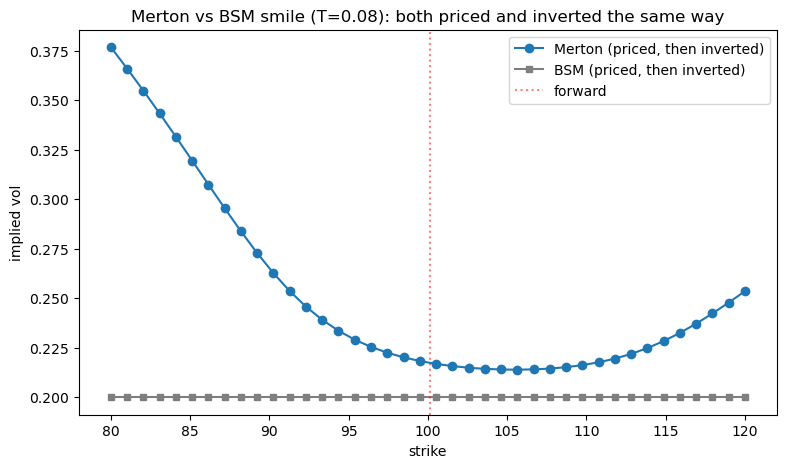

In [3]:
from calibration.implied_vol import bsm_implied_vol
from models.bsm import bsm_price

T_short = 0.08
strikes = np.linspace(80, 120, 40)

# Merton: price then invert
merton_prices = np.array([merton_cos_price(S0, R, Q, T_short, SIGMA, LAM, MU_J, DELTA_J, K, "call")
                          for K in strikes])
merton_ivs = [bsm_implied_vol(p, S0, K, T_short, R, "call", b=R-Q)
              for p, K in zip(merton_prices, strikes)]

# BSM: price then invert, the SAME round-trip, so flatness is demonstrated not asserted
bsm_prices = np.array([bsm_price(S0, K, T_short, R, SIGMA, "call", b=R-Q) for K in strikes])
bsm_ivs = [bsm_implied_vol(p, S0, K, T_short, R, "call", b=R-Q)
           for p, K in zip(bsm_prices, strikes)]

F = S0 * np.exp((R - Q) * T_short)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(strikes, merton_ivs, "o-", color="tab:blue", label="Merton (priced, then inverted)")
ax.plot(strikes, bsm_ivs, "s-", color="tab:gray", markersize=4,
        label="BSM (priced, then inverted)")
ax.axvline(F, color="red", ls=":", alpha=0.5, label="forward")
ax.set_xlabel("strike"); ax.set_ylabel("implied vol")
ax.set_title(f"Merton vs BSM smile (T={T_short}): both priced and inverted the same way")
ax.legend()
plt.show()

## 4. What building and validating Merton taught

### The COS refactor: independence makes the pricer reusable

Pricing Merton required no new pricer. The COS method depends on the model
*only* through its characteristic function, so once the COS core was refactored
to take pre-evaluated char func values plus cumulants (rather than calling
Heston by name), Merton pricing became a thin wrapper: compute Merton's char
func and cumulants, hand the numbers to the same core. Heston, Merton, and Kou
all feed one model-agnostic engine.

This is the practical payoff of the independence structure. Because the
diffusion and jumps are independent, the char func factorises
($\phi = \phi_{\text{diff}} \cdot \phi_{\text{jump}}$) and the cumulants add,
and both fall straight into a COS pricer that only ever sees numbers. Clean
theory produced a clean interface.

### Validation: analytic limits are necessary but not sufficient

Merton passed a battery of analytic-limit tests, and it is worth being clear on
what each did and did not certify:

- **BSM reduction** ($\lambda = 0$): confirms the diffusion part and drift, with
  jumps switched off. Says nothing about jump pricing.
- **Martingale check** ($\phi(-i) = S_0 e^{(r-q)\tau}$): certifies the
  compensator $\kappa$, evaluated with jumps *on*. A structural identity.
- **$\phi(0) = 1$**, **cumulant reduction**, **put-call parity**: normalisation,
  isolated cumulant correctness, and internal call/put consistency.

Every one of these is a *limit or an identity*. None tests that Merton prices an
option *correctly when jumps are on*. Parity comes closest but only checks the
call and put agree with each other; both could be wrong by the same amount.

The test that actually certifies jump pricing is **COS versus Monte Carlo**. The
MC simulator draws the real process (diffusion plus Poisson jumps) with no
shared machinery, so agreement is genuine independent confirmation. Result:
z-score 0.79 (COS 6.877 vs MC 6.882 +/- 0.007 on 2M paths), the COS price well
inside the MC confidence interval, residual consistent with COS truncation
rather than bias. The z-score, not an eyeballed tolerance, is the honest
statement of agreement: a correct pricer sits within a few standard errors of a
correct MC estimate.

### A subtlety that matters for accuracy: the jump variance

The second cumulant carries $\lambda\tau(\mu_J^2 + \delta_J^2)$, not
$\lambda\tau\,\delta_J^2$. The extra $\mu_J^2$ is the mean-squared jump size,
because the compound-Poisson second moment is $E[Y^2] = \text{Var}(Y) + E[Y]^2
= \delta_J^2 + \mu_J^2$. Dropping it makes the truncation range too narrow and
loses COS accuracy in the wings, precisely where jump models are supposed to
add value. A silent-accuracy bug, not a crash, so it is caught by validation
rather than by an error.

### The payoff: jumps produce short-dated skew that diffusions cannot

The final figure is the point of the whole exercise. At a short maturity
(T = 0.08, about 29 DTE) the Merton implied-vol curve sits well above the flat
diffusion volatility on both wings and is strongly left-skewed (left wing far
higher than right), driven by $\mu_J < 0$.

Three features, each meaningful:

- **A smile exists at all.** A pure diffusion gives a flat line; the jumps bend
  it into a smile. BSM cannot produce this.
- **It is skewed, not symmetric.** Downward jumps ($\mu_J < 0$) lift the
  downside wing more than the upside, the equity-skew direction, produced from a
  jump parameter rather than fitted as a shape.
- **The steepness persists at short maturity.** A jump can occur in any interval
  however short, so it keeps weight in the short-dated tail. A pure diffusion's
  smile flattens toward the diffusion vol as $\tau \to 0$; the jump model does
  not.

This is the direct answer to last week's puzzle: the steep 29 DTE SPX skew that
pinned SVI's $\rho$ near -1 and that Heston (Markovian, mean-reverting variance)
flattens away too fast. Merton generates exactly that shape from first
principles. Thursday: calibrate it to the real slice and measure how close it
gets.